<a href="https://colab.research.google.com/github/RafaXzaviero/PengolahanCitraDigital/blob/main/1U_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 📘 PROYEK PENGOLAHAN CITRA DIGITAL — SEGMENTASI CITRA
# Model: U-NET (Baseline)
# Evaluasi: IoU, Dice, Pixel Accuracy
# ============================================================

# 1️⃣ Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2️⃣ Import Library Dasar
import os, glob, cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("✅ Semua library telah dimuat dengan sukses.")

Mounted at /content/drive
✅ Semua library telah dimuat dengan sukses.


Jumlah gambar ditemukan: 290
Jumlah mask ditemukan  : 290

📥 Membaca semua gambar & mask...


100%|██████████| 290/290 [01:06<00:00,  4.34it/s]



✅ Dataset selesai dimuat!
Bentuk gambar: (290, 256, 256, 3)
Bentuk mask  : (290, 256, 256, 1)

📊 Data terbagi:
Train : 202 sampel
Val   : 44 sampel
Test  : 44 sampel


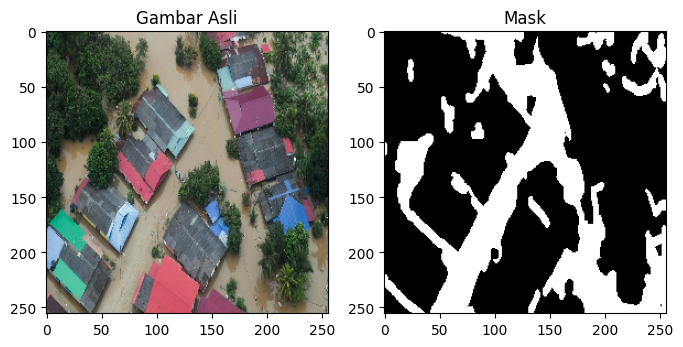

In [2]:
# ============================================================
# 📦 PENGAMBILAN DATASET DARI GOOGLE DRIVE
# ============================================================

path_gambar = "/content/drive/MyDrive/Colab Notebooks/dataset/Image/"
path_mask   = "/content/drive/MyDrive/Colab Notebooks/dataset/Mask/"

# Ambil semua file gambar & mask (.jpg atau .png)
gambar_paths = sorted(glob.glob(os.path.join(path_gambar, "*.jpg"))) + sorted(glob.glob(os.path.join(path_gambar, "*.png")))
mask_paths   = sorted(glob.glob(os.path.join(path_mask, "*.jpg")))   + sorted(glob.glob(os.path.join(path_mask, "*.png")))

print(f"Jumlah gambar ditemukan: {len(gambar_paths)}")
print(f"Jumlah mask ditemukan  : {len(mask_paths)}")

assert len(gambar_paths) == len(mask_paths), "❌ Jumlah gambar dan mask tidak sama!"

# Fungsi bantu untuk membaca gambar & mask
IMG_SIZE = 256

def baca_gambar(path, size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    img = img.astype(np.float32) / 255.0
    return img

def baca_mask(path, size=IMG_SIZE):
    msk = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    msk = cv2.resize(msk, (size, size))
    msk = (msk > 127).astype(np.float32)
    msk = np.expand_dims(msk, axis=-1)
    return msk

# Membaca semua data
print("\n📥 Membaca semua gambar & mask...")
gambar = np.array([baca_gambar(p) for p in tqdm(gambar_paths)], dtype=np.float32)
mask   = np.array([baca_mask(p) for p in tqdm(mask_paths)], dtype=np.float32)

print("\n✅ Dataset selesai dimuat!")
print("Bentuk gambar:", gambar.shape)
print("Bentuk mask  :", mask.shape)

# Split data 70/15/15
x_temp, x_test, y_temp, y_test = train_test_split(gambar, mask, test_size=0.15, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.1765, random_state=42)

print(f"\n📊 Data terbagi:")
print(f"Train : {len(x_train)} sampel")
print(f"Val   : {len(x_val)} sampel")
print(f"Test  : {len(x_test)} sampel")

# Cek contoh data
idx = np.random.randint(0, len(x_train))
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(x_train[idx]); plt.title("Gambar Asli")
plt.subplot(1,2,2); plt.imshow(y_train[idx].squeeze(), cmap='gray'); plt.title("Mask")
plt.show()

In [3]:
# ============================================================
# 🧠 MODEL U-NET (BASELINE)
# ============================================================

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout

def unet_model(input_size=(256,256,3)):
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    c4 = Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = MaxPooling2D()(c4)

    # Bottleneck
    c5 = Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, 3, activation='relu', padding='same')(c5)

    # Decoder
    u6 = UpSampling2D()(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(512, 3, activation='relu', padding='same')(c6)

    u7 = UpSampling2D()(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(256, 3, activation='relu', padding='same')(c7)

    u8 = UpSampling2D()(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = Conv2D(128, 3, activation='relu', padding='same')(c8)

    u9 = UpSampling2D()(c8)
    u9 = concatenate([u9, c1])
    c9 = Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = Conv2D(64, 3, activation='relu', padding='same')(c9)

    outputs = Conv2D(1, 1, activation='sigmoid')(c9)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = unet_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ============================================================
# ⚙️ FUNGSI METRIK, KOMPILASI MODEL, DAN CALLBACK
# ============================================================

@tf.keras.utils.register_keras_serializable()
def iou_metric(y_true, y_pred, smooth=1e-7):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

@tf.keras.utils.register_keras_serializable()
def dice_coefficient(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

@tf.keras.utils.register_keras_serializable()
def pixel_accuracy(y_true, y_pred):
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    y_true_bin = tf.cast(y_true, tf.float32)
    correct = tf.reduce_sum(tf.cast(tf.equal(y_true_bin, y_pred_bin), tf.float32))
    total = tf.cast(tf.size(y_true_bin), tf.float32)
    return correct / (total + 1e-7)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[iou_metric, dice_coefficient, pixel_accuracy]
)

# Callback
model_saver = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/model_unet_best.h5",
    monitor='val_iou_metric',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("✅ Model siap untuk dilatih.")

✅ Model siap untuk dilatih.


In [5]:
# ============================================================
# 🚀 TRAINING MODEL
# ============================================================

EPOCHS = 100
BATCH_SIZE = 8

riwayat = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[model_saver],
    verbose=1
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficient: 0.0607 - iou_metric: 0.0421 - loss: 0.6813 - pixel_accuracy: 0.6081   
Epoch 1: val_iou_metric improved from -inf to 0.62276, saving model to /content/drive/MyDrive/Colab Notebooks/model_unet_best.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - dice_coefficient: 0.0656 - iou_metric: 0.0459 - loss: 0.6806 - pixel_accuracy: 0.6096 - val_dice_coefficient: 0.7665 - val_iou_metric: 0.6228 - val_loss: 0.6187 - val_pixel_accuracy: 0.7915
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - dice_coefficient: 0.6283 - iou_metric: 0.4674 - loss: 0.5594 - pixel_accuracy: 0.7382
Epoch 2: val_iou_metric did not improve from 0.62276
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 477ms/step - dice_coefficient: 0.6302 - iou_metric: 0.4695 - loss: 0.5585 - pixel_accuracy: 0.7390 - val_dice_coefficient: 0.7262 - val_iou_metric: 0.5726 - val_loss: 0.5235 - val_pixel_accuracy: 0.8012
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - dice_coefficient: 0.6787 - iou_metric: 0.5236 - loss: 0.5178 - pixel_accuracy: 0.7593
Epoch 3: val_iou_metric improved from 0.62276 to 0.66715, saving model to /content/drive/MyDrive/Colab Notebooks/model_unet_best.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 532ms/step - dice_coefficient: 0.6795 - iou_metric: 0.5245 - loss: 0.5171 - pixel_accuracy: 0.7600 - val_dice_coefficient: 0.7981 - val_iou_metric: 0.6671 - val_loss: 0.4449 - val_pixel_accuracy: 0.8030
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - dice_coefficient: 0.7664 - iou_metric: 0.6265 - loss: 0.4348 - pixel_accuracy: 0.8104
Epoch 4: val_iou_metric did not improve from 0.66715
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 481ms/step - dice_coefficient: 0.7650 - iou_metric: 0.6249 - loss: 0.4355 - pixel_accuracy: 0.8099 - val_dice_coefficient: 0.7659 - val_iou_metric: 0.6214 - val_loss: 0.4241 - val_pixel_accuracy: 0.8190
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - dice_coefficient: 0.7322 - iou_metric: 0.5848 - loss: 0.4248 - pixel_accuracy: 0.8125
Epoch 5: val_iou_metric improved from 0.66715 to 0.69268, saving model to /content/drive/MyDrive/Colab Notebooks/model_unet_best.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 599ms/step - dice_coefficient: 0.7331 - iou_metric: 0.5858 - loss: 0.4244 - pixel_accuracy: 0.8127 - val_dice_coefficient: 0.8175 - val_iou_metric: 0.6927 - val_loss: 0.3744 - val_pixel_accuracy: 0.8406
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - dice_coefficient: 0.7695 - iou_metric: 0.6279 - loss: 0.4081 - pixel_accuracy: 0.8232
Epoch 6: val_iou_metric did not improve from 0.69268
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 498ms/step - dice_coefficient: 0.7699 - iou_metric: 0.6285 - loss: 0.4073 - pixel_accuracy: 0.8237 - val_dice_coefficient: 0.7973 - val_iou_metric: 0.6631 - val_loss: 0.3719 - val_pixel_accuracy: 0.8385
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - dice_coefficient: 0.8103 - iou_metric: 0.6833 - loss: 0.3519 - pixel_accuracy: 0.8566
Epoch 7: val_iou_metric improved from 0.69268 to 0.69538, saving model to /content/drive/MyDrive/Colab Notebooks/model_unet_best.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 693ms/step - dice_coefficient: 0.8097 - iou_metric: 0.6824 - loss: 0.3524 - pixel_accuracy: 0.8563 - val_dice_coefficient: 0.8190 - val_iou_metric: 0.6954 - val_loss: 0.3678 - val_pixel_accuracy: 0.8386
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - dice_coefficient: 0.8005 - iou_metric: 0.6710 - loss: 0.3553 - pixel_accuracy: 0.8581
Epoch 8: val_iou_metric did not improve from 0.69538
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 481ms/step - dice_coefficient: 0.8002 - iou_metric: 0.6706 - loss: 0.3559 - pixel_accuracy: 0.8577 - val_dice_coefficient: 0.8066 - val_iou_metric: 0.6762 - val_loss: 0.3763 - val_pixel_accuracy: 0.8422
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - dice_coefficient: 0.8051 - iou_metric: 0.6771 - loss: 0.3594 - pixel_accuracy: 0.8510
Epoch 9: val_iou_metric did not improve from 0.69538
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 486ms/step - dice_coefficient: 0.8049 - iou_metric: 0.6768 - loss: 0.3596 - pixel_accuracy: 0.8509 - val_dice_coe

...

26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 723ms/step - dice_coefficient: 0.8534 - iou_metric: 0.7462 - loss: 0.2894 - pixel_accuracy: 0.8881 - val_dice_coefficient: 0.8692 - val_iou_metric: 0.7704 - val_loss: 0.2741 - val_pixel_accuracy: 0.8846
Epoch 27/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - dice_coefficient: 0.8646 - iou_metric: 0.7633 - loss: 0.2478 - pixel_accuracy: 0.9009
Epoch 27: val_iou_metric did not improve from 0.77041
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 483ms/step - dice_coefficient: 0.8647 - iou_metric: 0.7634 - loss: 0.2481 - pixel_accuracy: 0.9008 - val_dice_coefficient: 0.8675 - val_iou_metric: 0.7680 - val_loss: 0.2647 - val_pixel_accuracy: 0.8848
Epoch 28/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - dice_coefficient: 0.8694 - iou_metric: 0.7700 - loss: 0.2558 - pixel_accuracy: 0.8963
Epoch 28: val_iou_metric did not improve from 0.77041
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 489ms/step - dice_coefficient: 0.8691 - iou_metric: 0.7696 - loss: 0.2559 - pixel_accuracy: 0.8963 - val_dice

26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 663ms/step - dice_coefficient: 0.8657 - iou_metric: 0.7646 - loss: 0.2555 - pixel_accuracy: 0.8975 - val_dice_coefficient: 0.8760 - val_iou_metric: 0.7800 - val_loss: 0.2500 - val_pixel_accuracy: 0.8946
Epoch 30/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - dice_coefficient: 0.8637 - iou_metric: 0.7622 - loss: 0.2602 - pixel_accuracy: 0.8987
Epoch 30: val_iou_metric did not improve from 0.78001
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 487ms/step - dice_coefficient: 0.8641 - iou_metric: 0.7628 - loss: 0.2596 - pixel_accuracy: 0.8989 - val_dice_coefficient: 0.8757 - val_iou_metric: 0.7799 - val_loss: 0.2613 - val_pixel_accuracy: 0.8920
Epoch 31/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - dice_coefficient: 0.8806 - iou_metric: 0.7881 - loss: 0.2344 - pixel_accuracy: 0.9062
Epoch 31: val_iou_metric did not improve from 0.78001
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 488ms/step - dice_coefficient: 0.8803 - iou_metric: 0.7875 - loss: 0.2350 - pixel_accuracy: 0.9061 - val_dice

26/26 ━━━━━━━━━━━━━━━━━━━━ 25s 967ms/step - dice_coefficient: 0.8969 - iou_metric: 0.8144 - loss: 0.2031 - pixel_accuracy: 0.9205 - val_dice_coefficient: 0.8771 - val_iou_metric: 0.7826 - val_loss: 0.2652 - val_pixel_accuracy: 0.8914
Epoch 38/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - dice_coefficient: 0.8934 - iou_metric: 0.8095 - loss: 0.2159 - pixel_accuracy: 0.9162
Epoch 38: val_iou_metric did not improve from 0.78255
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 479ms/step - dice_coefficient: 0.8934 - iou_metric: 0.8096 - loss: 0.2154 - pixel_accuracy: 0.9163 - val_dice_coefficient: 0.8765 - val_iou_metric: 0.7808 - val_loss: 0.2803 - val_pixel_accuracy: 0.8953
Epoch 39/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - dice_coefficient: 0.8953 - iou_metric: 0.8116 - loss: 0.1992 - pixel_accuracy: 0.9212
Epoch 39: val_iou_metric improved from 0.78255 to 0.78823, saving model to /content/drive/MyDrive/Colab Notebooks/model_unet_best.h5


26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 592ms/step - dice_coefficient: 0.8953 - iou_metric: 0.8117 - loss: 0.1993 - pixel_accuracy: 0.9212 - val_dice_coefficient: 0.8810 - val_iou_metric: 0.7882 - val_loss: 0.2665 - val_pixel_accuracy: 0.8983
Epoch 40/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - dice_coefficient: 0.8958 - iou_metric: 0.8119 - loss: 0.1950 - pixel_accuracy: 0.9232
Epoch 40: val_iou_metric did not improve from 0.78823
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 495ms/step - dice_coefficient: 0.8959 - iou_metric: 0.8120 - loss: 0.1953 - pixel_accuracy: 0.9230 - val_dice_coefficient: 0.8803 - val_iou_metric: 0.7875 - val_loss: 0.2567 - val_pixel_accuracy: 0.8981
Epoch 41/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - dice_coefficient: 0.9074 - iou_metric: 0.8316 - loss: 0.1893 - pixel_accuracy: 0.9252
Epoch 41: val_iou_metric did not improve from 0.78823
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 491ms/step - dice_coefficient: 0.9071 - iou_metric: 0.8312 - loss: 0.1895 - pixel_accuracy: 0.9251 - val_dice

26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 724ms/step - dice_coefficient: 0.9041 - iou_metric: 0.8258 - loss: 0.1907 - pixel_accuracy: 0.9246 - val_dice_coefficient: 0.8825 - val_iou_metric: 0.7907 - val_loss: 0.2495 - val_pixel_accuracy: 0.8968
Epoch 45/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - dice_coefficient: 0.9023 - iou_metric: 0.8228 - loss: 0.1788 - pixel_accuracy: 0.9309
Epoch 45: val_iou_metric did not improve from 0.79070
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 484ms/step - dice_coefficient: 0.9026 - iou_metric: 0.8232 - loss: 0.1788 - pixel_accuracy: 0.9309 - val_dice_coefficient: 0.8773 - val_iou_metric: 0.7834 - val_loss: 0.2723 - val_pixel_accuracy: 0.8905
Epoch 46/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - dice_coefficient: 0.9155 - iou_metric: 0.8446 - loss: 0.1719 - pixel_accuracy: 0.9335
Epoch 46: val_iou_metric did not improve from 0.79070
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 493ms/step - dice_coefficient: 0.9154 - iou_metric: 0.8444 - loss: 0.1720 - pixel_accuracy: 0.9335 - val_dice

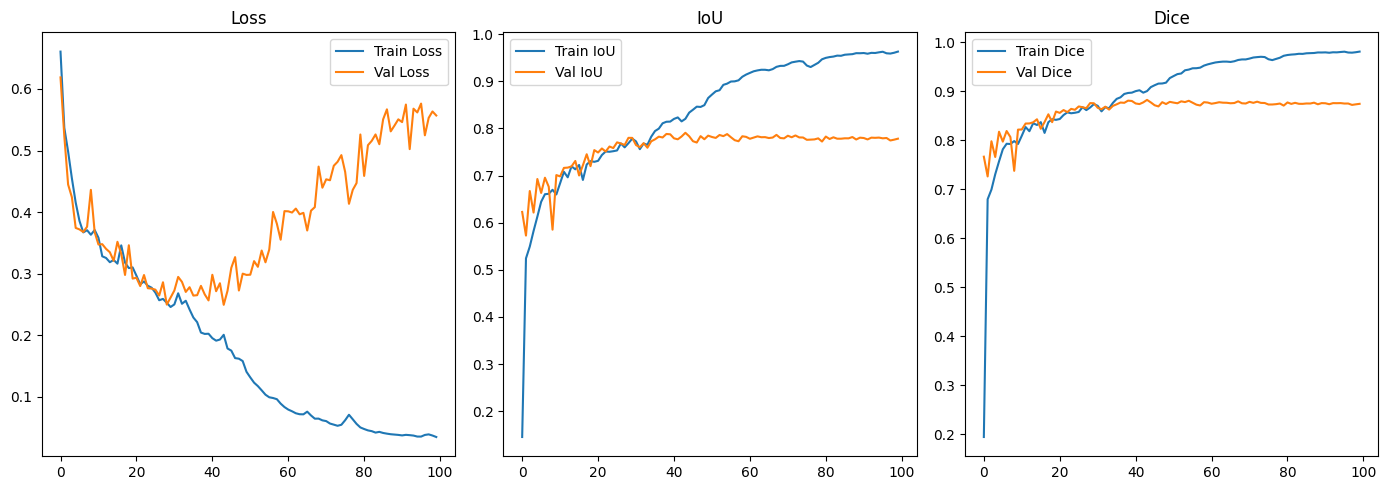

In [6]:
# ============================================================
# 📈 VISUALISASI HASIL TRAINING
# ============================================================
def plot_training(history):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history['iou_metric'], label='Train IoU')
    plt.plot(history.history['val_iou_metric'], label='Val IoU')
    plt.title('IoU')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history.history['dice_coefficient'], label='Train Dice')
    plt.plot(history.history['val_dice_coefficient'], label='Val Dice')
    plt.title('Dice')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training(riwayat)

In [7]:
# ============================================================
# 📊 EVALUASI MODEL DAN PREDIKSI
# ============================================================
print("\n📊 Evaluasi pada data test:")
hasil_test = model.evaluate(x_test, y_test, batch_size=BATCH_SIZE, verbose=1)
for nama, nilai in zip(model.metrics_names, hasil_test):
    print(f"{nama:<25}: {nilai:.4f}")


📊 Evaluasi pada data test:
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - dice_coefficient: 0.8793 - iou_metric: 0.7868 - loss: 0.5220 - pixel_accuracy: 0.9040
loss                     : 0.5196
compile_metrics          : 0.7816


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


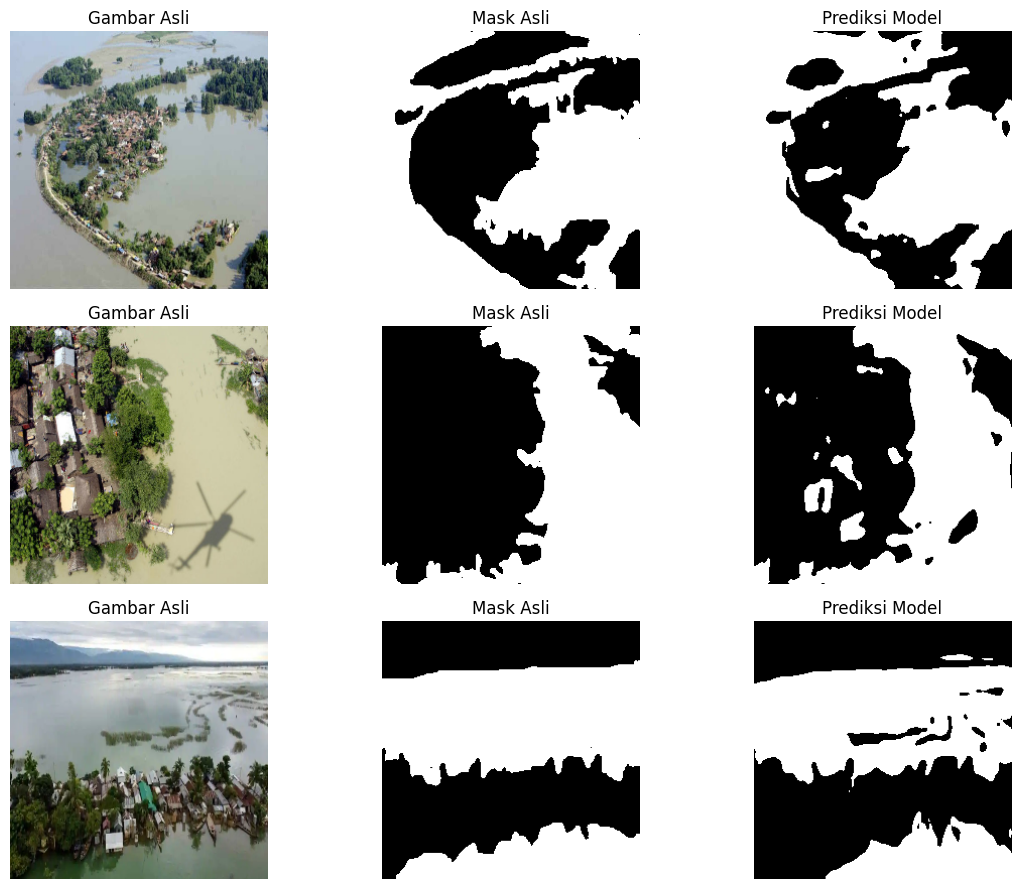

In [8]:
# ============================================================
# 🖼️ VISUALISASI PREDIKSI
# ============================================================
def tampilkan_prediksi(model, x_data, y_true, n=5):
    plt.figure(figsize=(12, n * 3))
    for i in range(n):
        idx = np.random.randint(0, len(x_data))
        gambar = x_data[idx]
        mask_asli = y_true[idx].squeeze()
        pred = model.predict(np.expand_dims(gambar, 0))[0].squeeze()
        pred_bin = (pred > 0.5).astype(np.float32)

        plt.subplot(n, 3, 3*i+1)
        plt.imshow(gambar)
        plt.title("Gambar Asli"); plt.axis("off")

        plt.subplot(n, 3, 3*i+2)
        plt.imshow(mask_asli, cmap='gray')
        plt.title("Mask Asli"); plt.axis("off")

        plt.subplot(n, 3, 3*i+3)
        plt.imshow(pred_bin, cmap='gray')
        plt.title("Prediksi Model"); plt.axis("off")
    plt.tight_layout(); plt.show()

tampilkan_prediksi(model, x_test, y_test, n=3)